In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorNeuropixelsProjectCache
import tqdm
from scipy.ndimage import gaussian_filter1d
import pre_process_spikes as pps
import lstm_module as lstm 
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from captum.attr import IntegratedGradients
import sys
import pandas as pd
import os

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [9]:
output_dir = r"Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022"
output_dir = Path(output_dir)
cache = VisualBehaviorNeuropixelsProjectCache.from_local_cache(cache_dir=output_dir)
session_id = 1044385384 # Arbitrary pick
session = cache.get_ecephys_session(ecephys_session_id=session_id)
behavior_id = session.behavior_session_id
behavior = cache.get_behavior_session(behavior_id)
chan = session.get_channels()
df_path = Path(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data') / f'session_{session_id}' / f'session_{session_id}_info.csv'
df      = pd.read_csv(df_path)

In [10]:
# change unit_id in df to be the index
df.set_index('unit_id', inplace=True)
# map cluster_id such that 1->2, 2->3, 3->1, 4->4, 5->5 as type int
df['cluster_id'] = df['cluster_id'].map({0:0, 1:2, 2:3, 3:1, 4:4, 5:5}).astype(int)
print(df.head())

           location   probe  firing_rate  dist_from_source  cluster_id
unit_id                                                               
1049374910    VISpm  probeB     8.577549       1305.332525           2
1049374988    VISpm  probeB     0.547925       1365.633553           2
1049373561      POL  probeB    16.918544       2911.231698           0
1049373556      POL  probeB    16.652535       2911.231698           0
1049373138      PoT  probeB    19.336021       3287.960158           0


In [11]:
units = session.get_units()
channels = session.get_channels()
spike_times = session.spike_times
units = units.merge(channels, left_on='peak_channel_id', right_index=True)
units = units[(units.isi_violations < 0.5) &
                                      (units.presence_ratio > 0.9) &
                                      (units.amplitude_cutoff < 0.1) &
                                      (units.firing_rate > 0.1)]

In [243]:
bin_size = 0.004
start = int(behavior.stimulus_presentations.start_time[behavior.stimulus_presentations.active].iloc[1])
stop  = int(behavior.stimulus_presentations.end_time[behavior.stimulus_presentations.active].iloc[-1])
print(start, stop)

26 3629


In [35]:
spikes_obj = pps.pre_process_spikes(units, spike_times,bin_size=0.004, sigma=3)
spikes_obj.getSpkMat(start, stop)
spikes_obj.convolve_with_gaussian()
spikes_obj.zscore()

100%|██████████| 741/741 [01:08<00:00, 10.78it/s]


In [242]:
probeC = session.get_lfp(session.probes[session.probes.name == 'probeC'].index[0])
# channel ids for VISp
visp_df = chan.loc[probeC.channel][chan.loc[probeC.channel]['structure_acronym'].str.contains('VISp')]
num_channels = len(visp_df)
lfp_slice = probeC.sel(time=slice(start,stop), channel=visp_df.index)
# resample data from 1250 Hz to 250 Hz to match the spike data
data = stats.zscore(lfp_slice[::5,:].values, axis=0) 
print(data.shape)
print(spikes_obj.spkMat.shape)
# make sure the data is the same length as the spike data
if data.shape[0] > spikes_obj.spkMat.shape[0]:
    data = data[:spikes_obj.spkMat.shape[0],:]

(900752, 20)
(900750, 741)


In [60]:
input_size = spikes_obj.spkMat.shape[1]
hidden_size = 50
num_layers = 1
seqlength = 750

In [10]:
# Preprocess data
num_trials = int(data.shape[0] / seqlength)
X = spikes_obj.spkMat[:num_trials * seqlength, :]
lfp = data[:num_trials * seqlength, :]

X_reshaped = np.reshape(X, (num_trials, seqlength, X.shape[1]))
lfp_reshaped = np.reshape(lfp, (num_trials, seqlength, lfp.shape[1]))

X_train, X_test, y_train, y_test = train_test_split(X_reshaped, lfp_reshaped, test_size=0.2, random_state=42)

X_train = X_train.reshape(X_train.shape[0] * X_train.shape[1], X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0] * X_test.shape[1], X_test.shape[2])

y_train = y_train.reshape(y_train.shape[0] * y_train.shape[1], y_train.shape[2])
y_test = y_test.reshape(y_test.shape[0] * y_test.shape[1], y_test.shape[2]) 

X_trainT = torch.tensor(X_train).float()
y_trainT = torch.tensor(y_train).float()
X_testT = torch.tensor(X_test).float()
y_testT = torch.tensor(y_test).float()

# remove non-tensor variables to free up memory
del X, lfp, X_reshaped, lfp_reshaped, X_train, X_test, y_train, y_test

print(X_trainT.shape, y_trainT.shape)
print(X_testT.shape, y_testT.shape)

torch.Size([720000, 741]) torch.Size([720000, 20])
torch.Size([180750, 741]) torch.Size([180750, 20])


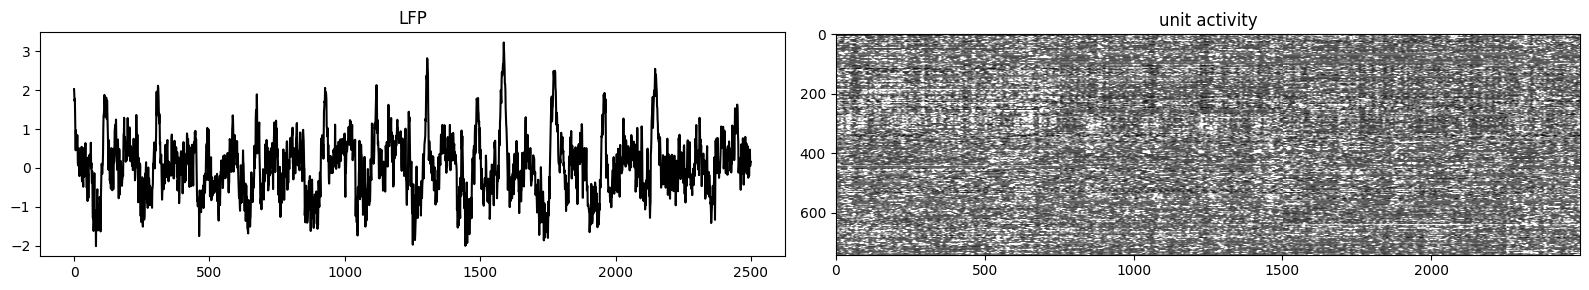

In [10]:
fig, ax = plt.subplots(1,2,figsize=(16, 3))

ax[0].plot(y_trainT.numpy()[:int(10/bin_size),10],'k',label='LFP')
# ax[0].plot(stats.zscore(np.mean(X_trainT.cpu().detach().numpy()[:int(10/bin_size),:], axis=1)),'r',label='unit activity')
ax[0].set_title('LFP')

ax[1].imshow(X_trainT.numpy()[:int(10/bin_size),:].T, vmin=-1, vmax=1, cmap='gray')
ax[1].set_title('unit activity')

plt.tight_layout()
plt.show()

In [19]:
criterion = torch.nn.MSELoss()
num_epochs = 15
lossesAll = np.zeros((y_trainT.shape[1], num_epochs))

# initialize dictionary to store trained models 
models = {}

for chani in range(num_channels):
    sys.stdout.write('\r' + 'Training model for channel ' + str(chani + 1) + ' out of ' + str(num_channels))
    model = lstm.process_model(lstm.LSTMnet(input_size, hidden_size, num_layers), seqlength, criterion, device)
    models[chani] = model
    losses = model.train(X_trainT, y_trainT[:,chani].unsqueeze(1) , num_epochs)
    lossesAll[chani,:] = losses

Finished epoch 15/15hannel 19 out of 20

Text(0.5, 1.0, 'Model loss')

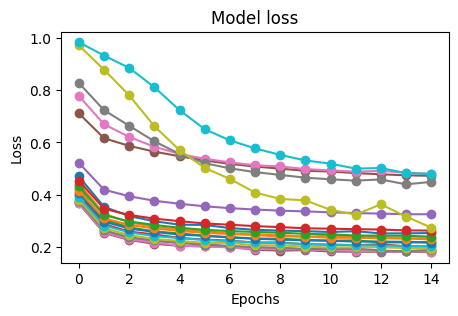

In [22]:
fig,ax = plt.subplots(1,1,figsize=(5,3))

ax.plot(lossesAll.T,'o-')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Model loss')

In [29]:
model_scores = pd.DataFrame(columns=['r2_train', 'r2_test'])

for chani in range(num_channels):
    yHat_train = models[chani].evaluate(X_trainT)
    r2_train = r2_score(y_trainT[:,chani].cpu().detach().numpy(), yHat_train)
    yHat_test = models[chani].evaluate(X_testT)
    r2_test = r2_score(y_testT[:,chani].cpu().detach().numpy(), yHat_test)
    model_scores.loc[chani] = [r2_train, r2_test]    

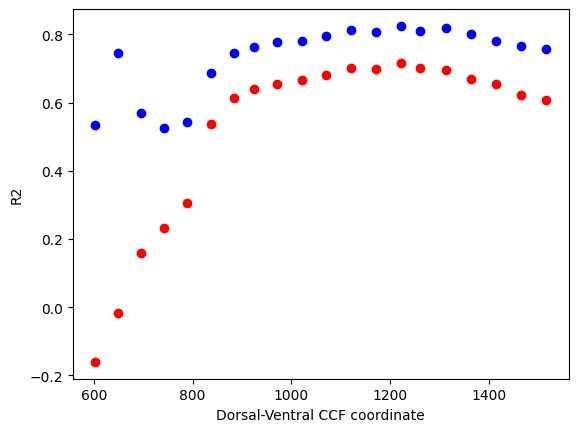

In [40]:
plt.scatter(visp_df['dorsal_ventral_ccf_coordinate'], model_scores['r2_train'], color = 'b', label='train')
plt.scatter(visp_df['dorsal_ventral_ccf_coordinate'], model_scores['r2_test'], color = 'r', label='test')
plt.xlabel('Dorsal-Ventral CCF coordinate')
plt.ylabel('R2')
plt.show()

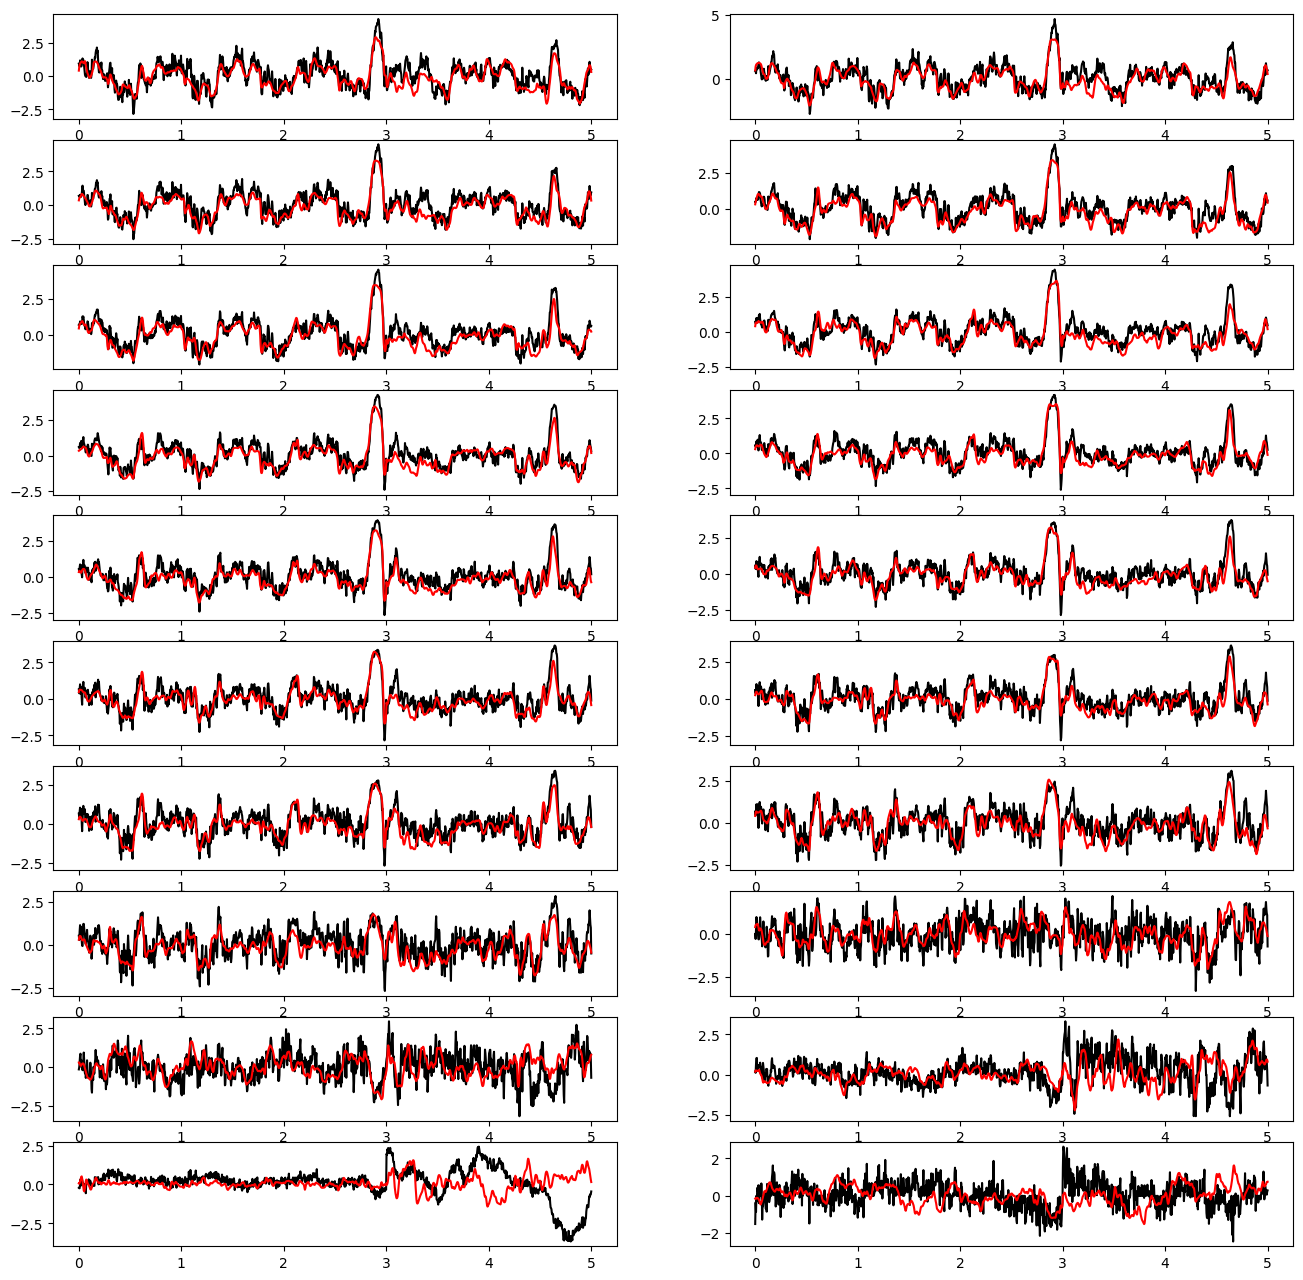

In [61]:
fig, ax = plt.subplots(int(np.ceil(num_channels/2)),2, figsize=(16, 16))

for chani in range(num_channels):
    yHat_test = models[chani].evaluate(X_testT)
    ax.flat[chani].plot(np.linspace(0,5,int(5/bin_size)), y_testT.cpu().detach().numpy()[:int(5/bin_size),chani],'k',label='LFP')
    ax.flat[chani].plot(np.linspace(0,5,int(5/bin_size)), yHat_test[:int(5/bin_size)],'r',label='LSTM')


In [75]:
# save the models
os.makedirs(output_dir / 'models' / str(session_id), exist_ok=True)
for idx, model in enumerate(models):
    filename = output_dir / 'models' / str(session_id) / f'lstm_model_{idx}.pt'
    torch.save(models[idx].model, filename)

In [78]:
# check if a variable models exists otherwise load it from the saved models
if 'models' not in locals():
    models = {}
    for idx in range(num_channels):
        filename = output_dir / 'models' / str(session_id) / f'lstm_model_{idx}.pt'
        model = torch.load(filename)
        models[idx] = model

C:\Users\SB13FLPC018\AppData\Local\Temp\ipykernel_29048\2594851869.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(filename)


In [12]:
del probeC, lfp_slice, data 

In [ ]:
# X_testT = X_testT.to(device)
dur = 720
X_attr = spikes_obj.spkMat[:int(dur/bin_size), :] # first 720 seconds of data
X_attr = torch.tensor(X_attr).float()

# for chani in range(num_channels):
# # Initialize the attribution algorithm with the model
#     sys.stdout.write('running atribution analysis on chan ' + str(chani) +'.\n')
#     # mdl = models[chani].model.train()
#     mdl = models[chani].train().to('cpu')
#     integrated_gradients = IntegratedGradients(mdl)
#     filename = output_dir / 'models' / str(session_id) / f'attribution_scores_{chani}.npy' 
#     attributions = []
#     for i in tqdm.tqdm(range(0,X_attr.shape[0],100)):
#         attributions.append(integrated_gradients.attribute(X_attr[i:i+100,:].contiguous(),  target=0,  n_steps=50))
#     attributions = torch.cat(attributions)
#     attributions = attributions.cpu().detach().numpy()
#     np.save(filename, attributions, 'allow_pickle=True')

torch.Size([180000, 741])
(180001, 20)


In [81]:
units_part = units[['firing_rate', 'anterior_posterior_ccf_coordinate', 'dorsal_ventral_ccf_coordinate',
            'left_right_ccf_coordinate', 'structure_acronym', 'probe_id']].copy()

# for each channel, calculate the mean attribution score for each unit and add it to the dataframe
for chani in range(num_channels):
    filename = output_dir / 'models' / str(session_id) / f'attribution_scores_{chani}.npy' 
    attributions = np.load(filename, allow_pickle=True)
    attributions = np.mean(attributions, axis=0)
    units_part.loc[:,'attribution_' + str(chani)] = attributions

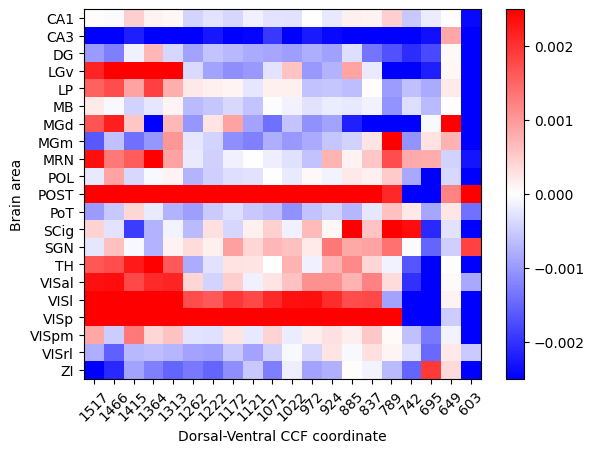

In [82]:
mean_attr = units_part[['structure_acronym', 'attribution_0', 'attribution_1', 'attribution_2', 'attribution_3', 
    'attribution_4', 'attribution_5', 'attribution_6', 'attribution_7', 'attribution_8', 'attribution_9', 
    'attribution_10', 'attribution_11', 'attribution_12', 'attribution_13', 'attribution_14', 'attribution_15', 
    'attribution_16', 'attribution_17', 'attribution_18', 'attribution_19']].groupby('structure_acronym').mean() # .apply(lambda x: x.abs().mean())

# plot the mean attribution scores for all areas as a matrix
plt.imshow(mean_attr.values, aspect='auto', vmin=-0.0025, vmax=0.0025, cmap='bwr')
plt.colorbar()
# add areas names to the plot
plt.yticks(np.arange(mean_attr.shape[0]), mean_attr.index) 
plt.ylabel('Brain area')
# add channel depth from visp_df to the plot
plt.xticks(np.arange(20), visp_df['dorsal_ventral_ccf_coordinate'].astype(int) , rotation=45)
plt.xlabel('Dorsal-Ventral CCF coordinate')
plt.show()

In [153]:
# merge units_part on df with the index being the unit_id
df2 = df.merge(units_part.drop(columns=['firing_rate', 'structure_acronym']), left_index=True, right_index=True)
# save the row ilocs in units_part that are in df2
locs2save = units_part.index.isin(df2.index)

print(df2.shape)
print(units_part.shape)
print(df2.head())


(613, 29)
(741, 26)
           location   probe  firing_rate  dist_from_source  cluster_id  \
1049374910    VISpm  probeB     8.577549       1305.332525           2   
1049374988    VISpm  probeB     0.547925       1365.633553           2   
1049373561      POL  probeB    16.918544       2911.231698           0   
1049373556      POL  probeB    16.652535       2911.231698           0   
1049373138      PoT  probeB    19.336021       3287.960158           0   

            anterior_posterior_ccf_coordinate  dorsal_ventral_ccf_coordinate  \
1049374910                             7935.0                          925.0   
1049374988                             7925.0                          648.0   
1049373561                             8132.0                         3730.0   
1049373556                             8132.0                         3730.0   
1049373138                             8166.0                         4138.0   

            left_right_ccf_coordinate    probe_id  att

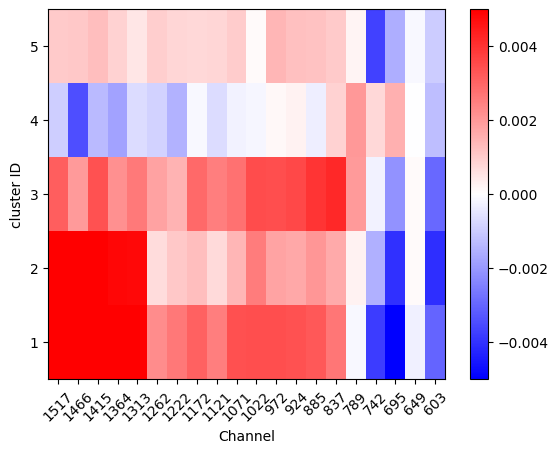

In [85]:
# get the mean attribution scores for each cluster_id across all channels
mean_attr = df2[['cluster_id', 'attribution_0', 'attribution_1', 'attribution_2', 'attribution_3', 
    'attribution_4', 'attribution_5', 'attribution_6', 'attribution_7', 'attribution_8', 'attribution_9', 
    'attribution_10', 'attribution_11', 'attribution_12', 'attribution_13', 'attribution_14', 'attribution_15', 
    'attribution_16', 'attribution_17', 'attribution_18', 'attribution_19']].groupby('cluster_id').mean()

# plot the mean attribution scores for all cluster_ids as a matrix
plt.imshow(mean_attr.values, aspect='auto', vmin=-0.005, vmax=0.005, cmap='bwr')
plt.ylim([0.5, 5.5])
plt.ylabel('cluster ID')
plt.xticks(np.arange(num_channels), visp_df['dorsal_ventral_ccf_coordinate'].astype(int) , rotation=45)
plt.xlabel('Channel')
plt.colorbar()
plt.show()


In [331]:
# load attribution scores for a specific channel 
chan2use = 5
filename = output_dir / 'models' / str(session_id) / f'attribution_scores_{chan2use}.npy'
attributions = np.load(filename, allow_pickle=True)
attributions = attributions[:,locs2save]

stim_st  = behavior.stimulus_presentations.start_time[behavior.stimulus_presentations.active].values
stim_st = stim_st[stim_st < dur]
stim_st = stim_st[1:]

# given spikes_obj.timestamps and stim_st and stim_end, get snippets of attributions around each stimulus presentation
nbins = int(0.75/bin_size)
t = np.linspace(-0.25, 0.5, nbins)

attributions_snippets = np.zeros((len(stim_st), nbins, attributions.shape[1]))
X_attr_snippets = np.zeros((len(stim_st), nbins, X_attr.shape[1]))
lfp_snippets = np.zeros((len(stim_st), nbins))

for i in range(len(stim_st)):
    start = np.argmin(np.abs(spikes_obj.timestamps - (stim_st[i]-.25)))
    attributions_snippets[i,:,:] = attributions[start:start+nbins,:]
    X_attr_snippets[i,:,:] = X_attr[start:start+nbins,:].numpy()
    lfp_snippets[i,:] = data[start:start+nbins,chan2use]
    
X_attr_snippets = X_attr_snippets[:,:,locs2save]
    

           location  attribution_5  cluster_id
1049375795     VISl       0.015000           1
1049375408     VISp       0.015071           2
1049375279     POST       0.015203           0
1049375346     VISp       0.015962           2
1049376428       DG       0.016089           0
1049374774      CA1       0.016150           0
1049375362     VISp       0.016386           2
1049375351     VISp       0.028152           1
1049375877     VISl       0.028211           1
1049375350     VISp       0.029257           1


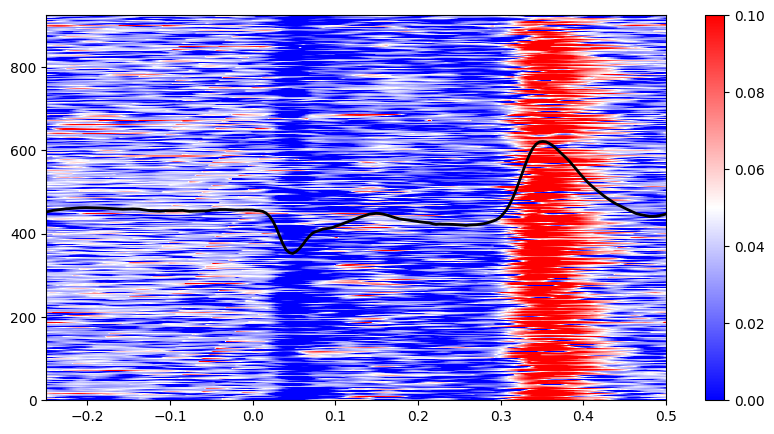

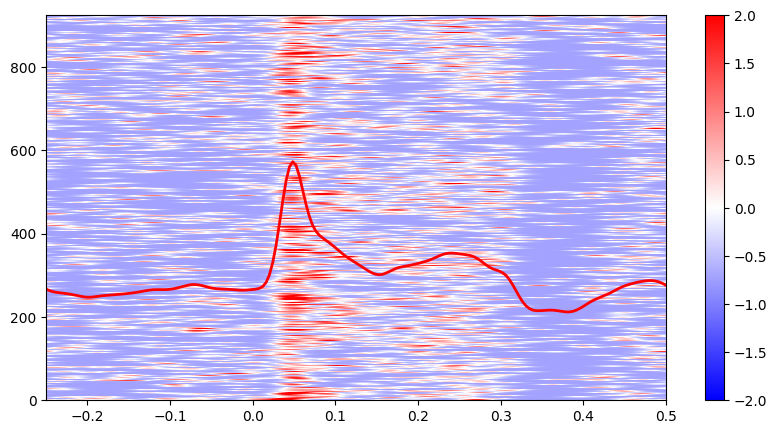

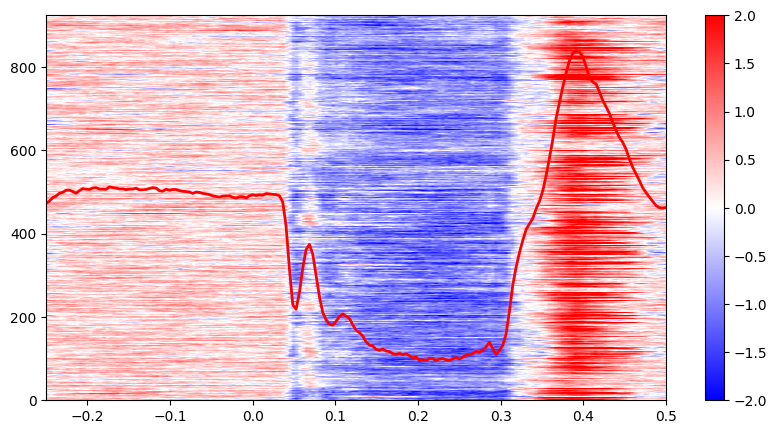

In [332]:
# find the k neurons with highest attribution across time where k=10
max_neurons = np.argsort(np.mean(attributions, axis=0))[-10:]
max_neuron = max_neurons[9]
# find the neuron with the highest attribution across time
# max_neuron = np.argmax(np.mean(attributions, axis=0))
# plot the attribution snippets for the neuron with the highest attribution
fig, ax = plt.subplots(1,1,figsize=(10, 5))
im = ax.imshow(attributions_snippets[:, :, max_neuron], aspect='auto', cmap='bwr', vmin=0, vmax=.1, extent=[-0.25, 0.5, 0, len(stim_st)])
# plot the average on top
avg_attr = np.mean(attributions_snippets[:, :, max_neuron], axis=0)
ax.plot(t, 2000 * avg_attr + 400, 'k', linewidth=2)
plt.colorbar(im)

# print(df2.iloc[max_neuron,:])
fig, ax = plt.subplots(1,1,figsize=(10, 5))
im2 = ax.imshow(X_attr_snippets[:, :, max_neuron], aspect='auto', cmap='bwr', extent=[-0.25, 0.5, 0, len(stim_st)],vmin=-2, vmax=2)
avr_spk = np.mean(X_attr_snippets[:, :, max_neuron], axis=0)
ax.plot(t, 300 * avr_spk + 400, 'r', linewidth=2)
plt.colorbar(im2)

fig, ax = plt.subplots(1,1,figsize=(10, 5))
im3 = ax.imshow(lfp_snippets, aspect='auto', cmap='bwr', extent=[-0.25, 0.5, 0, len(stim_st)],vmin=-2, vmax=2)
avr_lfp = np.mean(lfp_snippets, axis=0)
ax.plot(t, 300 * avr_lfp + 400, 'r', linewidth=2)
plt.colorbar(im3)

print(df2.iloc[max_neurons,:][['location',f'attribution_{chan2use}', 'cluster_id']])

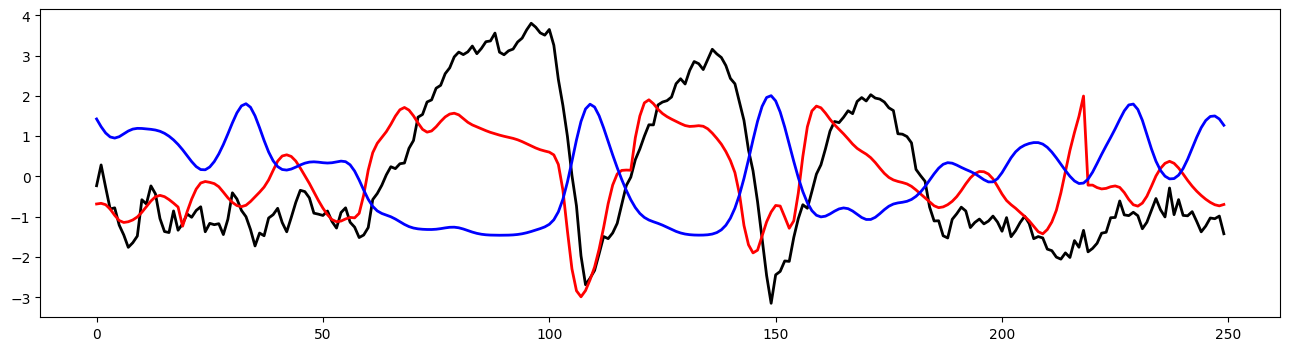

In [380]:
a = np.argmin(np.abs(spikes_obj.timestamps - (479.5 + 4.0240)))
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(data[a:a+250,5], 'k', linewidth=2)
# add the attribution on top
ax.plot(stats.zscore(np.mean(attributions[a:a+250, df2['location'].str.contains('VISp')], axis=1)), 'r', linewidth=2)
ax.plot(stats.zscore(np.mean(X_attr[:, locs2save].numpy()[a:a+250, df2['location'].str.contains('VISp')],axis=1)),'b', linewidth=2)

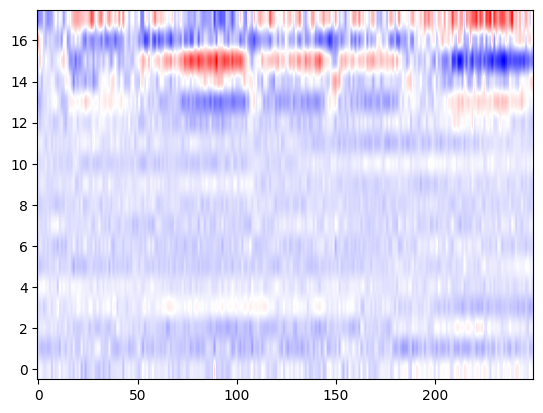

In [333]:
# plot the CSD of the LFP snippet
lfp_snippet = data[a:a+250,:]
csd = np.diff(lfp_snippet.T, axis=0, n=2)
plt.imshow(csd, aspect='auto', cmap='bwr', origin='lower')

In [377]:
np.mean(X_attr[:, locs2save].numpy()[:, df2['location'].str.contains('VISp')],axis=1)

(180000,)

(-0.7953767090446382, 0.12237883093684081)

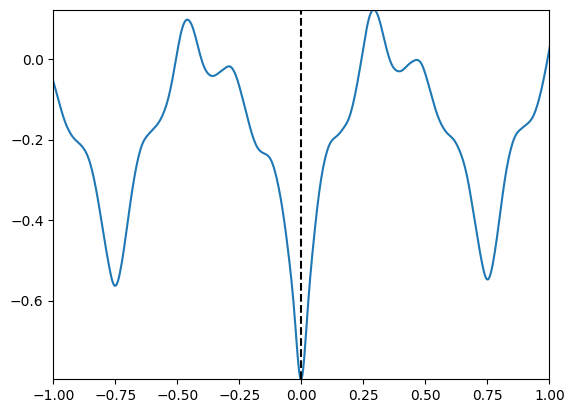

In [374]:
# plot the cross-correlation between the LFP and the mean attribution of VISp neurons df2['location'].str.contains('VISp')]
from scipy import signal
sig1 = data[:attributions.shape[0],chan2use]
sig2 = np.mean(attributions[:, df2['location'].str.contains('VISp')], axis=1)
sig3 = X_attr[:, locs2save].numpy()
sig3 = np.mean(sig3[:, df2['location'].str.contains('VISp')], axis=1)

corr = signal.correlate(sig2, sig3 , mode='same')
lags = signal.correlation_lags(sig2.size, sig1.size, mode="same")

corr = corr / (np.std(sig2) * np.std(sig3) * len(sig3))

plt.plot(lags*bin_size, corr)
plt.plot([0,0], [np.min(corr), np.max(corr)], 'k--')
plt.xlim([-1, 1])
plt.ylim([np.min(corr), np.max(corr)])